# Meeting Agents Problem

Implementation of the meeting agents problem from AIMA Exercise 3.3.

## Problem Description



**Goal**: Move two agents to the same location in minimal time. **Both agents must move in each turn** (neither can stay put).

### Distance Map

```text
 A-----78-----B--
  \           |  \
   65         87  90
    \         |     \
     C---50---D--20--E
```

### Problem Formulation

**State**: Defines locations of both agents and the distance (D) between locations
- Agent 1 location (C1)
- Agent 2 location (C2)

**Initial State**:
- Location map as shown above
- C1 = Agent 1 = A
- C2 = Agent 2 = B

**Actions**:
- `travel(agent1, location1, agent2, location2)` - both agents move simultaneously to adjacent locations
- **Constraint**: Both agents must move to a different location (cannot stay at current location)

**Transition Model**:
- Both agents move from their current locations to adjacent locations via existing edges
- Neither agent can remain at their current location

**Goal Test**:
- Tests if both agents are in the same location

**Path Cost**:
- Step cost = max(D1, D2) where D1 and D2 are distances traveled by each agent
- Path cost = sum(step costs)
- Time is limited by the slower agent in each turn

### Admissible Heuristics Analysis
- (i) D(i,j) - straight-line distance
- (iii) D(i,j)/2 - half the straight-line distance

(i) and (iii) are admissible because:
- Straight line is always the shortest path (never overestimates)
- Halving it is even less (also never overestimates)

### Special Cases

1. **No Solution**: A connected graph can have no solution if E is excluded from graph and agents start at A and B
2. **Revisiting Cells**: Agent may have to visit same cell twice:
   - Map: C-A-B-E
   - Initial state: C1 = C, C2 = B
   - Steps:
     - travel(1, A), travel(2, E)
     - travel(1, B), travel(2, B)

## Implementation

### Imports

In [ ]:
# Import required modules
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().resolve().parent.parent))

from search4e import (
    Problem, astar_search, uniform_cost_search, greedy_bfs,
    breadth_first_search, weighted_astar_search,
    path_states, path_actions, report
)
import matplotlib.pyplot as plt
import networkx as nx

print("Modules imported successfully!")

### Meeting Agents Problem Class

Based on RouteProblem from search4e.ipynb, adapted for simultaneous multi-agent movement.

- **State**: `(loc1, loc2)` tuple representing locations of both agents
- **Actions**: `(dest1, dest2)` tuple of destination locations for both agents
- **Cost**: `max(d1, d2)` - the time taken is limited by the slower agent
- **Heuristic**: Minimum distance for either agent to reach the meeting point

In [ ]:
class MeetingAgentsProblem(Problem):
    """
    Problem where two agents must meet at the same location.
    Based on RouteProblem pattern from search4e.ipynb.
    
    State: (loc1, loc2) - locations of agent 1 and agent 2
    Actions: (dest1, dest2) - where each agent moves (both must move)
    Cost: max(distance1, distance2) - limited by slower agent
    """
    
    def __init__(self, initial, distances, locations=None):
        """
        Args:
            initial: (loc1, loc2) tuple of starting locations
            distances: dict of {(loc_a, loc_b): distance} pairs
            locations: optional dict of {location: (x, y)} for visualization
        """
        # Goal is any state where both agents are at same location
        super().__init__(initial, goal=None)
        self.distances = distances
        self.locations = locations or {}
        
        # Build neighbor map for quick lookup
        self.neighbors = {}
        for (loc1, loc2) in distances:
            if loc1 not in self.neighbors:
                self.neighbors[loc1] = []
            if loc2 not in self.neighbors:
                self.neighbors[loc2] = []
            if loc2 not in self.neighbors[loc1]:
                self.neighbors[loc1].append(loc2)
            if loc1 not in self.neighbors[loc2]:
                self.neighbors[loc2].append(loc1)
    
    def actions(self, state):
        """
        Return all possible joint actions where BOTH agents must move.
        Neither agent can stay at their current location.
        """
        loc1, loc2 = state
        
        # Possible moves for each agent (must move to neighbor)
        moves1 = self.neighbors.get(loc1, [])
        moves2 = self.neighbors.get(loc2, [])
        
        # Generate all combinations of moves
        return [(dest1, dest2) for dest1 in moves1 for dest2 in moves2]
    
    def result(self, state, action):
        """
        Apply action to get new state.
        Action is (dest1, dest2) tuple.
        """
        return action
    
    def action_cost(self, s, a, s1):
        """
        Cost is the maximum distance traveled by either agent.
        This represents the time taken (limited by slower agent).
        """
        loc1, loc2 = s
        dest1, dest2 = a
        
        # Calculate distance for each agent
        dist1 = self.distances.get((loc1, dest1), 0) if loc1 != dest1 else 0
        dist2 = self.distances.get((loc2, dest2), 0) if loc2 != dest2 else 0
        
        # Cost is the maximum (bottleneck is the slower agent)
        return max(dist1, dist2)
    
    def is_goal(self, state):
        """
        Goal is reached when both agents are at the same location.
        """
        loc1, loc2 = state
        return loc1 == loc2
    
    def h(self, node):
        """
        Heuristic: minimum distance for either agent to any potential meeting point.
        This is admissible because it never overestimates the true cost.
        """
        loc1, loc2 = node.state
        
        if loc1 == loc2:
            return 0
        
        # Get all possible locations
        all_locations = set(self.neighbors.keys())
        
        # Find minimum cost to reach any common meeting point
        min_cost = float('inf')
        
        for meeting_point in all_locations:
            # Use straight-line distance if locations provided, otherwise use 0
            if self.locations:
                # Estimate distance using straight-line (admissible)
                dist1 = self._straight_line_distance(loc1, meeting_point)
                dist2 = self._straight_line_distance(loc2, meeting_point)
            else:
                # Without location info, use simple heuristic
                dist1 = 0 if loc1 == meeting_point else 1
                dist2 = 0 if loc2 == meeting_point else 1
            
            # Cost is max of the two distances
            cost = max(dist1, dist2)
            min_cost = min(min_cost, cost)
        
        return min_cost
    
    def _straight_line_distance(self, loc1, loc2):
        """Helper to calculate straight-line distance between locations."""
        if loc1 == loc2:
            return 0
        if loc1 not in self.locations or loc2 not in self.locations:
            return 0
        
        x1, y1 = self.locations[loc1]
        x2, y2 = self.locations[loc2]
        return ((x2 - x1)**2 + (y2 - y1)**2)**0.5

print("MeetingAgentsProblem class defined!")

### Problem Instance: Exercise 3.3 Map

Define the distance map from the exercise:
```
 A-----78-----B--
  \           |  \
   65         87  90
    \         |     \
     C---50---D--20--E
```

In [ ]:
# Define the distance map (bidirectional)
distances = {
    ('A', 'B'): 78, ('B', 'A'): 78,
    ('A', 'C'): 65, ('C', 'A'): 65,
    ('B', 'D'): 87, ('D', 'B'): 87,
    ('B', 'E'): 90, ('E', 'B'): 90,
    ('C', 'D'): 50, ('D', 'C'): 50,
    ('D', 'E'): 20, ('E', 'D'): 20,
}

# Optional: Define locations for visualization (arranged to match diagram)
locations = {
    'A': (0, 2),
    'B': (4, 2),
    'C': (0, 0),
    'D': (3, 0),
    'E': (5, 0),
}

# Create problem instance: Agent 1 starts at A, Agent 2 starts at B
agents_initial = ('A', 'B')
agents_problem = MeetingAgentsProblem(agents_initial, distances, locations)

print("Meeting agents problem created!")
print(f"Initial state: Agent 1 at {agents_initial[0]}, Agent 2 at {agents_initial[1]}")
print(f"Goal: Both agents at the same location")
print(f"Number of locations: {len(set(k[0] for k in distances.keys()))}")

### Test Actions

Check what joint moves are available from the initial state.

In [ ]:
# Test available actions from initial state
available_actions = agents_problem.actions(agents_initial)

print(f"From initial state {agents_initial}, there are {len(available_actions)} possible joint actions:")
print("\nSample actions (Agent1 -> Loc1, Agent2 -> Loc2):")
for i, (dest1, dest2) in enumerate(sorted(available_actions)[:10], 1):
    cost = agents_problem.action_cost(agents_initial, (dest1, dest2), (dest1, dest2))
    print(f"  {i}. Agent1: {agents_initial[0]} → {dest1}, Agent2: {agents_initial[1]} → {dest2} (cost: {cost})")

### Solve with A* Search

In [ ]:
# Solve the problem with A* search
agents_solution = astar_search(agents_problem)

if agents_solution:
    print("Solution found!")
    print(f"\nPath from {agents_initial} to meeting point:")
    
    path = path_states(agents_solution)
    actions = path_actions(agents_solution)
    
    print(f"\nNumber of steps: {len(actions)}")
    print(f"Total cost: {agents_solution.path_cost}")
    
    print("\nDetailed path:")
    for i, state in enumerate(path):
        loc1, loc2 = state
        print(f"  Step {i}: Agent1 @ {loc1}, Agent2 @ {loc2}")
        if i < len(actions):
            action = actions[i]
            next_state = path[i + 1] if i + 1 < len(path) else state
            cost = agents_problem.action_cost(state, action, next_state)
            print(f"           → Action: ({action[0]}, {action[1]}) | Cost: {cost}")
    
    print(f"\n✓ Both agents meet at location: {path[-1][0]}")
else:
    print("No solution found!")

### Algorithm Comparison

In [ ]:
# Test multiple search algorithms
algorithms = [
    ("A* Search", astar_search),
    ("Uniform Cost Search", uniform_cost_search),
    ("Greedy Best-First Search", greedy_bfs),
    ("Weighted A* (w=1.4)", lambda p: weighted_astar_search(p, weight=1.4)),
    ("Breadth-First Search", breadth_first_search),
]

print("Testing different search algorithms on meeting agents problem:\n")
print("=" * 80)

results = {}

for name, algorithm in algorithms:
    print(f"\n{name}:")
    print("-" * 40)
    
    solution = algorithm(agents_problem)
    
    if solution and solution.path_cost < float('inf'):
        path = path_states(solution)
        actions = path_actions(solution)
        meeting_point = path[-1][0]
        
        print(f"  Solution found!")
        print(f"  Meeting point: {meeting_point}")
        print(f"  Path cost: {solution.path_cost:.2f}")
        print(f"  Number of steps: {len(actions)}")
        
        results[name] = solution
    else:
        print(f"  No solution found")
        results[name] = None

print("\n" + "=" * 80)

### Performance Report

In [ ]:
# Detailed performance comparison using report()
print("\nDetailed Performance Report")
print("=" * 100)
print("Format: nodes_explored | goal_tests | path_cost | num_actions | algorithm_name")
print("=" * 100)

searchers = [
    astar_search,
    uniform_cost_search,
    greedy_bfs,
    lambda p: weighted_astar_search(p, weight=1.4),
    breadth_first_search,
]

# Name the lambda functions
searchers[3].__name__ = "weighted_astar_1.4"

# Run the report
report(searchers, [agents_problem], verbose=True)

### Visualization

In [34]:
def visualize_agents(problem, solution=None, figsize=(16, 7)):
    """
    Visualize the meeting agents problem with side-by-side comparison.
    Left: Map structure only
    Right: Solution path with agent movements
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # Create graph visualization
    G = nx.Graph()
    
    # Add edges with weights
    for (loc1, loc2), dist in problem.distances.items():
        if loc1 < loc2:  # Avoid duplicate edges
            G.add_edge(loc1, loc2, weight=dist)
    
    # Use provided locations or spring layout
    pos = problem.locations if problem.locations else nx.spring_layout(G, seed=42)
    
    # Draw both subplots
    for ax in [ax1, ax2]:
        # Draw graph
        nx.draw_networkx_edges(G, pos, ax=ax, width=2, alpha=0.6)
        nx.draw_networkx_nodes(G, pos, ax=ax, node_color='lightblue', 
                             node_size=800, alpha=0.9)
        nx.draw_networkx_labels(G, pos, ax=ax, font_size=14, font_weight='bold')
        
        # Draw edge labels (distances)
        edge_labels = {(loc1, loc2): f"{dist}" 
                      for (loc1, loc2), dist in problem.distances.items() 
                      if loc1 < loc2}
        nx.draw_networkx_edge_labels(G, pos, edge_labels, ax=ax, font_size=10)
        
        # Highlight initial positions
        loc1_init, loc2_init = problem.initial
        ax.plot(*pos[loc1_init], 'go', markersize=20, label='Agent 1 start', zorder=5)
        ax.plot(*pos[loc2_init], 'rs', markersize=20, label='Agent 2 start', zorder=5)
        
        ax.set_aspect('equal')
        ax.axis('off')
    
    ax1.set_title('Problem Map\n', fontsize=13, fontweight='bold')
    ax1.legend(loc='center', fontsize=10)
    
    # Right plot: Add solution if provided
    if solution:
        path = path_states(solution)
        
        # Extract paths for each agent
        path1 = [state[0] for state in path]
        path2 = [state[1] for state in path]
        
        # Draw agent 1 path
        for i in range(len(path1) - 1):
            loc_from, loc_to = path1[i], path1[i+1]
            if loc_from != loc_to:
                x1, y1 = pos[loc_from]
                x2, y2 = pos[loc_to]
                ax2.annotate('', xy=(x2, y2), xytext=(x1, y1),
                           arrowprops=dict(arrowstyle='->', lw=2.5, color='green', alpha=0.8))
        
        # Draw agent 2 path
        for i in range(len(path2) - 1):
            loc_from, loc_to = path2[i], path2[i+1]
            if loc_from != loc_to:
                x1, y1 = pos[loc_from]
                x2, y2 = pos[loc_to]
                ax2.annotate('', xy=(x2, y2), xytext=(x1, y1),
                           arrowprops=dict(arrowstyle='->', lw=2.5, color='red', alpha=0.8))
        
        # Mark meeting point
        meeting_loc = path[-1][0]
        ax2.plot(*pos[meeting_loc], 'y*', markersize=40, label='Meeting point', zorder=6)
        
        ax2.set_title(f'A* Solution\nCost: {solution.path_cost:.0f} | Steps: {len(path)-1} | Meet at: {meeting_loc}',
                     fontsize=13, fontweight='bold')
        ax2.legend(loc='center', fontsize=10)
    else:
        ax2.set_title('No Solution', fontsize=13, fontweight='bold')
    
    plt.tight_layout()
    plt.show()



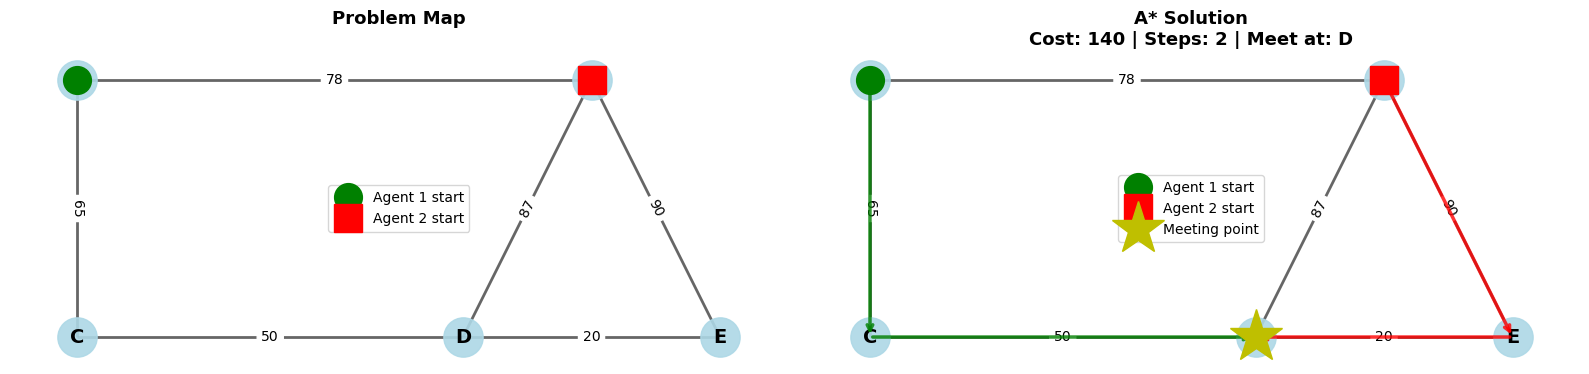

In [35]:
# Visualize problem and solution
visualize_agents(agents_problem, agents_solution)